## Key Concepts
* images -> pixels matrix
* audio -> waveform(numbers)

1. **Waveform**: Jab hum bolte hain, to hawa mein vibrations hoti hain. Computer is vibration ko numbers ki ek series (1D Array) mein save karta hai. Agar aap isko plot karein, to ye wave dikhti hai:

2. **Sampling Rate (sr)**: Ek second ki audio mein se computer kitni baar aawaz ko measure (sample) karta hai. Standard rate 22,050Hz ya 44,100Hz hota hai. Matlab 1 second ki audio mein 22,050 numbers hote hain!

3. **Spectrogram**: Ye sab se mazedar cheez hai. Agar hum waveform ko frequency aur time ke hissaab se todkar ek image bana dein, to use Spectrogram kehte hain. Iska fayda? Aap is image ko seedha apne purane CNN (Convolutional Neural Network) model mein daal sakte hain!

4. **MFCC (Mel-Frequency Cepstral Coefficients)**: Ye audio ke "features" hain jo इंसानी (human) hearing pattern ke mutabiq aawaz ko represent karte hain.

## Approaches we can work

**Method # 1**: ***Tabular Data Approach (Numerical Features)*** <br>
* Raw audio se statistical features nikale (jaise mean, standard deviation, ya MFCCs ke averages).

* Yeh bilkul ek CSV file ya Tabular dataset jaisa ban gaya, jahan har row ek audio file hai aur columns uske numerical features hain.

* Is par aap simple ML algorithms chalate hain jaise Logistic Regression, Random Forest, SVM, ya XGBoost.

* Jab data kam ho, computer resource kam hon, ya kaam bohot simple ho (jaise hamara Yes/No wala project).


**Method # 2**: ***Computer Vision Approach (Image Spectrograms)***
* Audio ko time aur frequency ke hissaab se poora transform karke matrix bana diya, jo ke ek Spectrogram Image ban gayi.

* Kiske jaisa treat hua: Yeh bilkul 2D Image Data ban gaya.

*  Is par aap CNNs (ResNet, VGG, MobileNet) chalate hain. Model ko pata hi nahi hota ke wo aawaz dekh raha hai, uske liye wo bas ek image hoti hai jahan patterns dhoondne hote hain.

* Real-world aur complex projects mein (jaise automatic speech recognition, sound event detection, bird sound matching).

## Architecting Your Audio AI Project: 3 Major Approaches


### **Approach 1: Off-the-Shelf Pre-trained Models (Direct Use)**

* **How it works**: Directly deploy state-of-the-art models (like Meta's HuBERT or Google's Audio Spectrogram Transformer) using pipelines without writing any training code.

* **Best For**: General use cases like generic Speech-to-Text, or standard sound classification (e.g., coughing, crying, car horns).

* **The Advantage**: Zero training required. You plug in the model from open hubs like Hugging Face and use it instantly.


### **Approach 2: Transfer Learning & Fine-Tuning (The Hybrid Approach)**

* **How it works**: Take a massive foundational model trained on millions of audio hours and retrain its final layer on a small, niche dataset.

* **Best For**: Specialized tasks, such as custom voice identification, localized accents, or medical audio analysis.

* **The Advantage**: High accuracy with minimal data (even 50–100 custom audio clips work perfectly because the model already understands basic acoustic patterns).


### **Approach 3: Training from Scratch using Open Datasets (Custom Modeling)**

* **How it works**: Build and train your custom neural network architecture using massive, freely available public data.

* **Best For**: Complete control over your engine or exploring foundational research.

* **Popular Data Repositories**:
  * LibriSpeech: Standard benchmarks for English speech recognition.

  * Google AudioSet: 2 million+ labeled 10-second clips tracking diverse environmental sounds.

  * Mozilla Common Voice: A massive multilingual dataset including diverse regional languages like Urdu.

------

## ***Approach 1: Off-the-Shelf Pre-trained Models (Direct Use)***

## Libraries Install and Import
Google Colab mein audio ke liye librosa pehle se hota hai. Hum visualization aur modeling ki libraries import karenge.

Audio processing ke liye ye Python libraries standard hain:

* **Librosa**: Audio files load karne aur features (MFCCs, Spectrograms) nikalne ke liye.

* **Soundfile**: Audio files ko save/load karne ke liye.

* **Matplotlib**: Waveforms aur Spectrograms visualize karne ke liye.

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

## Audio File Download aur Load Karein
Colab mein sample audio download karne ke liye ye command run karein (ye librosa ki apni testing files hain):

In [ ]:
# Librosa ki built-in example audio download karein (Trumpet ki aawaz)
audio_path = librosa.example('nutcracker')

# Audio ko load karein
# 'y' digital audio ka array hai, 'sr' sampling rate hai
y, sr = librosa.load(audio_path, duration=5.0) # sirf pehle 5 seconds

print(f"Audio array ka size: {y.shape}")
print(f"Sampling Rate: {sr}")

Audio array ka size: (110250,)
Sampling Rate: 22050


##  Audio ko Visualise Karein (Dekhein aawaz kaisi dikhti hai)
Ab is 1D array ko screen par plot karke dekhte hain:

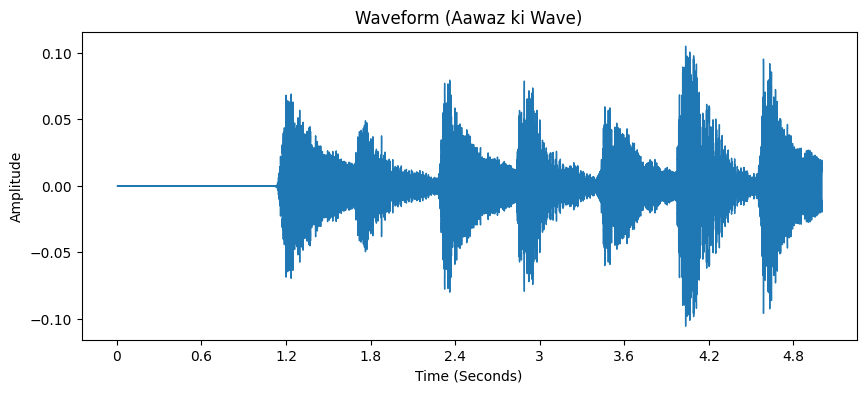

In [ ]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform (Aawaz ki Wave)')
plt.xlabel('Time (Seconds)')
plt.ylabel('Amplitude')
plt.show()

##  Spectrogram (Image) mein Badlein
audio ka spectrogram banana sab se zaroori hai taake aap isko feature ke tor par use kar sakein:

> Audio data ki sab se khoobsurat baat hi yehi hai ke end mein wo numbers ka ek matrix ($2D$ Array) ban jata hai, bilkul aik normal image ki tarah. Is matrix ka har number yeh batata hai ke us makhsoos time (X-axis) aur frequency (Y-axis) par aawaz kitni tez ya buland (loud) thi.

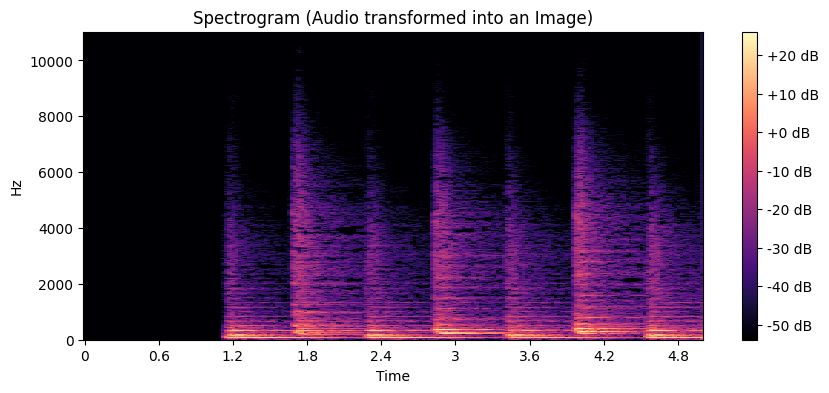

In [ ]:
# Audio ko Short-time Fourier Transform (STFT) ke zariye frequencies mein badlein
X = librosa.stft(y)
Xdb = librosa.amplitude_to_db(abs(X)) # Decibels mein convert karein matrix ko

# Plot Spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (Audio transformed into an Image)')
plt.show()

## Model Training in Colab
Hum high-level PyTorch ya TensorFlow direct use karne ki bajaye Hugging Face ka ek pre-trained model uthayenge aur use sirf few lines mein test karenge,

In [ ]:
!pip install transformers datasets evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


## Pre-trained Model Se Pipeline Banayein:
Hugging Face par pehle se bohot bade datasets (jaise Google ka AudioSet) par trained models maujood hain. Hum ek Audio Classification pipeline use karenge jo aawaz sun kar batayegi ke wo kis cheez ki aawaz hai:



In [ ]:
from transformers import pipeline

# Ek doosra open aur free model load karte hain (Meta ka HuBERT)
# Yeh bina kisi login/token ke chalta hai
classifier = pipeline("audio-classification", model="facebook/hubert-large-ls960-ft")

# Apni audio file isko dein (jo humne y aur sr mein load ki thi)
predictions = classifier(y, top_k=3)

# Results check karein
for pred in predictions:
    print(f"Class: {pred['label']}, Confidence: {round(pred['score'] * 100, 2)}%")

config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] HubertForSequenceClassification LOAD REPORT from: facebook/hubert-large-ls960-ft
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
projector.bias    | MISSING    | 
classifier.weight | MISSING    | 
projector.weight  | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Class: LABEL_0, Confidence: 51.93%
Class: LABEL_1, Confidence: 48.07%
